<a href="https://colab.research.google.com/github/jbranca2011-creator/dsrp_2/blob/main/Research_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

My question for the project: Does location have an affect on how much the cost for college is?

In [1]:
import csv
import pandas as pd

### **Cleaning** **dataset** **section**

In [2]:
college_csv= "/content/College_Scorecard_Cleaned.csv"
college_df= pd.read_csv(college_csv)
college_df.head()

,UNITID,INSTNM,STABBR,REGION,LOCALE,CONTROL,ADM_RATE,SAT_AVG,ACTCMMID,UGDS,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,PCTPELL,PCTFLOAN,RET_FT4,C150_4,GRAD_DEBT_MDN,MD_EARN_WNE_4YR,MD_EARN_WNE_P10
0,100654,Alabama A & M University,AL,5,12.0,1,0.5795,938.0,18.0,6124.0,27153.0,10024.0,18634.0,0.6298,0.7454,0.6989,0.2403,31000.0,54018.0,40628.0
1,100663,University of Alabama at Birmingham,AL,5,12.0,1,0.8818,1258.0,27.0,11635.0,28145.0,9098.0,22562.0,0.3402,0.4027,0.8009,0.6423,22300.0,64969.0,54501.0
2,100690,Amridge University,AL,5,12.0,2,NaN,NaN,NaN,241.0,NaN,7590.0,7590.0,0.7655,0.8097,NaN,1.0000,32189.0,50075.0,37621.0
3,100706,University of Alabama in Huntsville,AL,5,12.0,1,0.6857,1319.0,28.0,6591.0,27392.0,12132.0,26408.0,0.2464,0.3255,0.8425,0.6429,20705.0,81045.0,61767.0
4,100724,Alabama State University,AL,5,12.0,1,0.9755,976.0,18.0,3477.0,23586.0,11248.0,19576.0,0.7134,0.7420,0.6975,0.3034,31000.0,45998.0,34502.0


In [3]:
college_df

,UNITID,INSTNM,STABBR,REGION,LOCALE,CONTROL,ADM_RATE,SAT_AVG,ACTCMMID,UGDS,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,PCTPELL,PCTFLOAN,RET_FT4,C150_4,GRAD_DEBT_MDN,MD_EARN_WNE_4YR,MD_EARN_WNE_P10
0,100654,Alabama A & M University,AL,5,12.0,1,0.5795,938.0,18.0,6124.0,27153.0,10024.0,18634.0,0.6298,0.7454,0.6989,0.2403,31000.0,54018.0,40628.0
1,100663,University of Alabama at Birmingham,AL,5,12.0,1,0.8818,1258.0,27.0,11635.0,28145.0,9098.0,22562.0,0.3402,0.4027,0.8009,0.6423,22300.0,64969.0,54501.0
2,100690,Amridge University,AL,5,12.0,2,NaN,NaN,NaN,241.0,NaN,7590.0,7590.0,0.7655,0.8097,NaN,1.0000,32189.0,50075.0,37621.0
3,100706,University of Alabama in Huntsville,AL,5,12.0,1,0.6857,1319.0,28.0,6591.0,27392.0,12132.0,26408.0,0.2464,0.3255,0.8425,0.6429,20705.0,81045.0,61767.0
4,100724,Alabama State University,AL,5,12.0,1,0.9755,976.0,18.0,3477.0,23586.0,11248.0,19576.0,0.7134,0.7420,0.6975,0.3034,31000.0,45998.0,34502.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,487524,Husson University,ME,1,13.0,2,0.8095,1180.0,NaN,2618.0,35852.0,23304.0,23304.0,0.3881,0.7168,0.7535,0.5935,27000.0,62950.0,45025.0
1516,489937,Carolina University,NC,5,11.0,2,0.3954,NaN,NaN,460.0,32680.0,17575.0,17575.0,0.3726,0.4458,0.5636,0.2155,20287.0,52812.0,32864.0
1517,490805,Purdue University Northwest,IN,3,21.0,1,0.7236,1024.0,23.0,5671.0,15571.0,8675.0,16094.0,0.2806,0.2532,0.6570,0.4291,21229.0,73337.0,48318.0
1518,498562,Commonwealth University of Pennsylvania,PA,2,32.0,1,0.9309,1090.0,NaN,9210.0,25161.0,11046.0,22870.0,0.3179,0.5394,0.7757,0.5448,26000.0,58676.0,52416.0


In [4]:
college_df.shape

(1520, 20)

In [5]:
college_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UNITID           1520 non-null   int64  
 1   INSTNM           1520 non-null   object 
 2   STABBR           1520 non-null   object 
 3   REGION           1520 non-null   int64  
 4   LOCALE           1520 non-null   float64
 5   CONTROL          1520 non-null   int64  
 6   ADM_RATE         1383 non-null   float64
 7   SAT_AVG          948 non-null    float64
 8   ACTCMMID         915 non-null    float64
 9   UGDS             1520 non-null   float64
 10  COSTT4_A         1506 non-null   float64
 11  TUITIONFEE_IN    1520 non-null   float64
 12  TUITIONFEE_OUT   1520 non-null   float64
 13  PCTPELL          1520 non-null   float64
 14  PCTFLOAN         1520 non-null   float64
 15  RET_FT4          1509 non-null   float64
 16  C150_4           1511 non-null   float64
 17  GRAD_DEBT_MDN 

In [6]:
college_df.isna().sum()

,0
UNITID,0
INSTNM,0
STABBR,0
REGION,0
LOCALE,0
CONTROL,0
ADM_RATE,137
SAT_AVG,572
ACTCMMID,605
UGDS,0


In [7]:
college_df_filled = college_df.copy()

number_cols = college_df_filled.select_dtypes(include=['float64', 'int64']).columns

for col in number_cols:
    mean_value = college_df_filled[col].mean()
    college_df_filled[col] = college_df_filled[col].fillna(mean_value)

college_df_filled = college_df_filled.drop_duplicates()

print("Shape of DataFrame after filling NaNs and removing duplicates:")
print(college_df_filled.shape)

Shape of DataFrame after filling NaNs and removing duplicates:
(1520, 20)


In [8]:
print("Head of DataFrame after filling NaNs and removing duplicates:")
print(college_df_filled.head())

Head of DataFrame after filling NaNs and removing duplicates:
   UNITID                               INSTNM STABBR  REGION  LOCALE  \
0  100654             Alabama A & M University     AL       5    12.0   
1  100663  University of Alabama at Birmingham     AL       5    12.0   
2  100690                   Amridge University     AL       5    12.0   
3  100706  University of Alabama in Huntsville     AL       5    12.0   
4  100724             Alabama State University     AL       5    12.0   

   CONTROL  ADM_RATE      SAT_AVG   ACTCMMID     UGDS      COSTT4_A  \
0        1  0.579500   938.000000  18.000000   6124.0  27153.000000   
1        1  0.881800  1258.000000  27.000000  11635.0  28145.000000   
2        2  0.712014  1187.740506  24.496175    241.0  43288.204515   
3        1  0.685700  1319.000000  28.000000   6591.0  27392.000000   
4        1  0.975500   976.000000  18.000000   3477.0  23586.000000   

   TUITIONFEE_IN  TUITIONFEE_OUT  PCTPELL  PCTFLOAN   RET_FT4  C150_4  \

In [9]:
print("Info of DataFrame after filling NaNs and removing duplicates:")
college_df_filled.info()

Info of DataFrame after filling NaNs and removing duplicates:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UNITID           1520 non-null   int64  
 1   INSTNM           1520 non-null   object 
 2   STABBR           1520 non-null   object 
 3   REGION           1520 non-null   int64  
 4   LOCALE           1520 non-null   float64
 5   CONTROL          1520 non-null   int64  
 6   ADM_RATE         1520 non-null   float64
 7   SAT_AVG          1520 non-null   float64
 8   ACTCMMID         1520 non-null   float64
 9   UGDS             1520 non-null   float64
 10  COSTT4_A         1520 non-null   float64
 11  TUITIONFEE_IN    1520 non-null   float64
 12  TUITIONFEE_OUT   1520 non-null   float64
 13  PCTPELL          1520 non-null   float64
 14  PCTFLOAN         1520 non-null   float64
 15  RET_FT4          1520 non-null   float64
 16

In [10]:
college_df_filled

,UNITID,INSTNM,STABBR,REGION,LOCALE,CONTROL,ADM_RATE,SAT_AVG,ACTCMMID,UGDS,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,PCTPELL,PCTFLOAN,RET_FT4,C150_4,GRAD_DEBT_MDN,MD_EARN_WNE_4YR,MD_EARN_WNE_P10
0,100654,Alabama A & M University,AL,5,12.0,1,0.579500,938.000000,18.000000,6124.0,27153.000000,10024.0,18634.0,0.6298,0.7454,0.698900,0.2403,31000.0,54018.0,40628.0
1,100663,University of Alabama at Birmingham,AL,5,12.0,1,0.881800,1258.000000,27.000000,11635.0,28145.000000,9098.0,22562.0,0.3402,0.4027,0.800900,0.6423,22300.0,64969.0,54501.0
2,100690,Amridge University,AL,5,12.0,2,0.712014,1187.740506,24.496175,241.0,43288.204515,7590.0,7590.0,0.7655,0.8097,0.751822,1.0000,32189.0,50075.0,37621.0
3,100706,University of Alabama in Huntsville,AL,5,12.0,1,0.685700,1319.000000,28.000000,6591.0,27392.000000,12132.0,26408.0,0.2464,0.3255,0.842500,0.6429,20705.0,81045.0,61767.0
4,100724,Alabama State University,AL,5,12.0,1,0.975500,976.000000,18.000000,3477.0,23586.000000,11248.0,19576.0,0.7134,0.7420,0.697500,0.3034,31000.0,45998.0,34502.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,487524,Husson University,ME,1,13.0,2,0.809500,1180.000000,24.496175,2618.0,35852.000000,23304.0,23304.0,0.3881,0.7168,0.753500,0.5935,27000.0,62950.0,45025.0
1516,489937,Carolina University,NC,5,11.0,2,0.395400,1187.740506,24.496175,460.0,32680.000000,17575.0,17575.0,0.3726,0.4458,0.563600,0.2155,20287.0,52812.0,32864.0
1517,490805,Purdue University Northwest,IN,3,21.0,1,0.723600,1024.000000,23.000000,5671.0,15571.000000,8675.0,16094.0,0.2806,0.2532,0.657000,0.4291,21229.0,73337.0,48318.0
1518,498562,Commonwealth University of Pennsylvania,PA,2,32.0,1,0.930900,1090.000000,24.496175,9210.0,25161.000000,11046.0,22870.0,0.3179,0.5394,0.775700,0.5448,26000.0,58676.0,52416.0


### **Hypothisis Testing**

In [11]:
!pip install numpy
!pip install scipy
import numpy as np
import scipy.stats as stats

Hypothisis
Does location affect cost?

$\mu_1 = \mu_2$

$\mu_1 \neq \mu_2$

In [12]:
from scipy import stats

tuition_in = college_df_filled['TUITIONFEE_IN']
tuition_out = college_df_filled['TUITIONFEE_OUT']

t_statistic, p_value = stats.ttest_ind(tuition_in, tuition_out, equal_var=False)

alpha = 0.05

print("T-test (TUITIONFEE_IN vs. TUITIONFEE_OUT):\n  T-statistic: {t_statistic:.4f}\n  P-value: {p_value:.4f}\n  Alpha: {alpha}")

if p_value < alpha:
    print("  Conclusion: Reject H0. Significant difference in average tuition fees.")
elif p_value > alpha:
    print("  Conclusion: Fail to reject H0. No significant difference in average tuition fees.")
else:
    print("  Conclusion: P-value equals alpha. Further analysis may be needed.")

T-test (TUITIONFEE_IN vs. TUITIONFEE_OUT):
  T-statistic: {t_statistic:.4f}
  P-value: {p_value:.4f}
  Alpha: {alpha}
  Conclusion: Reject H0. Significant difference in average tuition fees.


In [21]:
print("Unique values and counts for REGION:")
display(college_df_filled['REGION'].value_counts())

Unique values and counts for REGION:


,count
REGION,
5,376
2,266
3,231
4,173
8,151
1,131
6,116
7,44
9,31


In [20]:
from scipy import stats

college_df_filled['Tuition_Category'] = college_df_filled.apply(
    lambda row: 'Same Tuition' if row['TUITIONFEE_IN'] == row['TUITIONFEE_OUT'] else 'Different Tuition',
    axis=1)

contingency_table = pd.crosstab(college_df_filled['STABBR'], college_df_filled['Tuition_Category'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

alpha = 0.05

print("\nChi-squared test for State (STABBR) vs. Tuition Category (Same/Different In-State/Out-of-State Tuitions):")
print("Chi-squared Statistic: {chi2:.4f}")
print("P-value: {p_value:.4f}")
print("Degrees of Freedom: {dof}")

if p_value < alpha:
    print("Conclusion: Reject H0 (alpha={alpha}). There is a significant association between the state (STABBR) and whether in-state and out-of-state tuition fees are the same or different.")
else:
    print("Conclusion: Fail to reject H0 (alpha={alpha}). There is no significant association between the state (STABBR) and whether in-state and out-of-state tuition fees are the same or different.")


Chi-squared test for State (STABBR) vs. Tuition Category (Same/Different In-State/Out-of-State Tuitions):
Chi-squared Statistic: {chi2:.4f}
P-value: {p_value:.4f}
Degrees of Freedom: {dof}
Conclusion: Reject H0 (alpha={alpha}). There is a significant association between the state (STABBR) and whether in-state and out-of-state tuition fees are the same or different.


# **Bar plot**

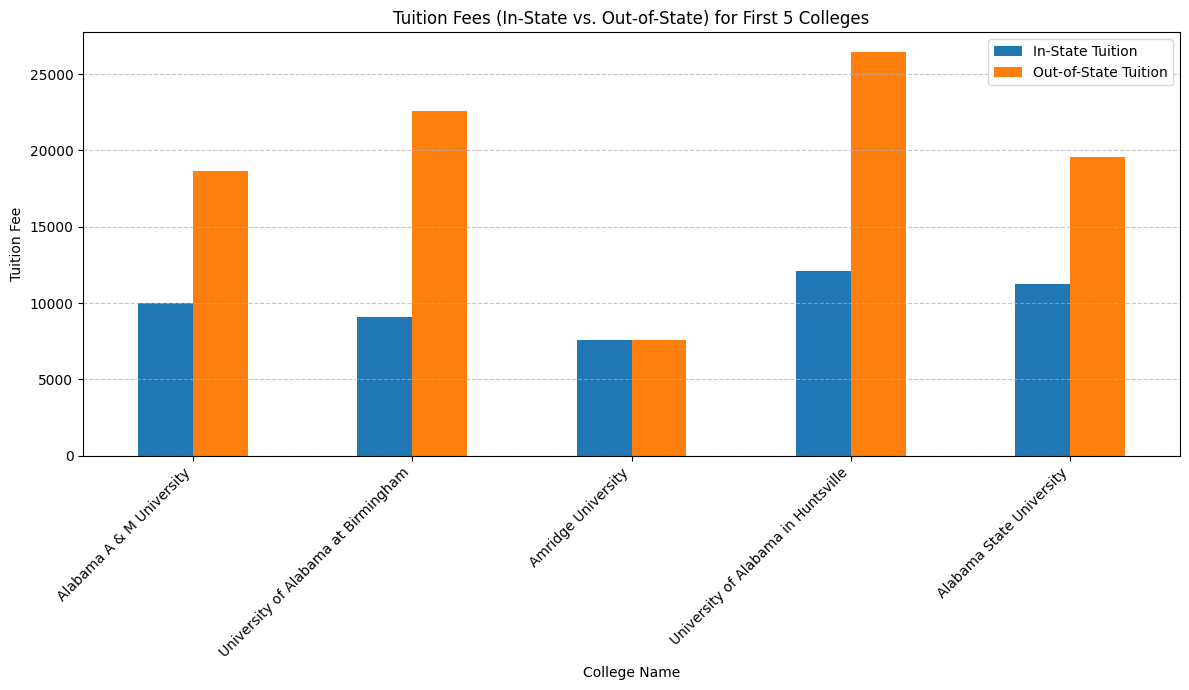

In [15]:
import matplotlib.pyplot as plt

data_to_plot = college_df_filled.head(5)[['INSTNM', 'TUITIONFEE_IN', 'TUITIONFEE_OUT']]

data_to_plot = data_to_plot.set_index('INSTNM')

data_to_plot.plot(kind='bar', figsize=(12, 7))

plt.title('Tuition Fees (In-State vs. Out-of-State) for First 5 Colleges')
plt.xlabel('College Name')
plt.ylabel('Tuition Fee')
plt.xticks(rotation=45, ha='right')
plt.legend(['In-State Tuition', 'Out-of-State Tuition'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()